Python : 3.12.2
Pandas : 2.3.3
NumPy  : 2.3.5
PROJECT_ROOT : /Users/hasheenadilmidesilva/Desktop/NetGuard
RAW_DATA_PATH: /Users/hasheenadilmidesilva/Desktop/NetGuard/data/raw
REPORTS_PATH : /Users/hasheenadilmidesilva/Desktop/NetGuard/reports/eda

DATASET OVERVIEW

TRAIN shape: (7381, 3)


,id,location,fault_severity
0,14121,location 118,1
1,9320,location 91,0
2,14394,location 152,1



TEST shape: (11171, 2)


,id,location
0,11066,location 481
1,18000,location 962
2,16964,location 491



EVENT_TYPE shape: (31170, 2)


...


RESOURCE_TYPE shape: (21076, 2)


,id,resource_type
0,6597,resource_type 8
1,8011,resource_type 8
2,2597,resource_type 8



SEVERITY_TYPE shape: (18552, 2)


,id,severity_type
0,6597,severity_type 2
1,8011,severity_type 2
2,2597,severity_type 2



MISSING VALUES

TRAIN
No missing values.

TEST
No missing values.

EVENT_TYPE
No missing values.

LOG_FEATURE
No missing values.

RESOURCE_TYPE
No missing values.

SEVERITY_TYPE
No missing values.

DUPLICATE CHECKS
train: total duplicate rows = 0
test: total duplicate rows = 0
event_type: total duplicate rows = 0
log_feature: total duplicate rows = 0
resource_type: total duplicate rows = 0
severity_type: total duplicate rows = 0

ID UNIQUENESS CHECKS
Train duplicate IDs: 0
Test duplicate IDs : 0

RELATIONAL DUPLICATE PAIRS
event_type duplicated (id, event_type): 0
resource_type duplicated (id, resource_type): 0
log_feature duplicated (id, log_feature): 0
Max severity_type rows per id: 1

TARGET DISTRIBUTION
                count  proportion
fault_severity                   
0                4784      0.6482
1                1871      0.2535
2                 726      0.0984


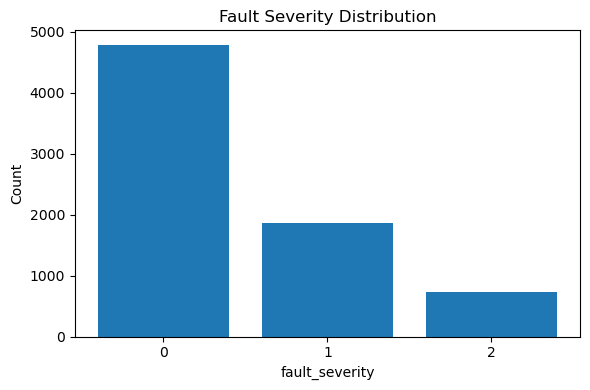


Imbalance ratio (majority/minority): 6.59

ID COVERAGE CHECK
Train/Test ID overlap: 0

EVENT_TYPE
Coverage train (%): 100.0
Coverage test  (%): 100.0
Unknown IDs      : 0

LOG_FEATURE
Coverage train (%): 100.0
Coverage test  (%): 100.0
Unknown IDs      : 0

RESOURCE_TYPE
Coverage train (%): 100.0
Coverage test  (%): 100.0
Unknown IDs      : 0

SEVERITY_TYPE
Coverage train (%): 100.0
Coverage test  (%): 100.0
Unknown IDs      : 0

EDA SUMMARY
                                 metric     value
0                            train_rows   7381.00
1                             test_rows  11171.00
2                      train_unique_ids   7381.00
3                       test_unique_ids  11171.00
4                 train_test_id_overlap      0.00
5              max_severity_rows_per_id      1.00
6                  majority_class_count   4784.00
7                  minority_class_count    726.00
8  imbalance_ratio_majority_to_minority      6.59

EDA COMPLETE
Saved files:
- /Users/hasheenadilmidesi

In [1]:
"""
01_data_understanding.ipynb

Purpose:
Perform concise EDA for the Telstra-style fault dataset.

What this notebook does:
1. Load all raw datasets safely
2. Check basic dataset structure
3. Check missing values and duplicates
4. Check target imbalance
5. Validate basic ID coverage
6. Produce only the final compact outputs needed for viva

Outputs saved to:
    ../reports/eda/
"""

# 1. Imports and Environment Setup

# sys is used to print the Python version
import sys

# Path helps create file paths in a clean way
from pathlib import Path

# numpy is used for numeric operations
import numpy as np

# pandas is used to load and inspect CSV files
import pandas as pd

# matplotlib is used to draw the class distribution chart
import matplotlib.pyplot as plt


try:
    from IPython.display import display
except Exception:
    display = None

# Show all columns when printing DataFrames
pd.set_option("display.max_columns", None)

# Make table output wider and easier to read
pd.set_option("display.width", 160)

# Fix random seed so results stay consistent
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Print software versions
print("Python :", sys.version.split()[0])
print("Pandas :", pd.__version__)
print("NumPy  :", np.__version__)


# 2. Paths

# This assumes the notebook is inside a folder like /notebooks
# So parent folder is treated as the project root
PROJECT_ROOT = Path.cwd().parent

# Raw CSV files are expected inside data/raw
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"

# Final EDA outputs will be saved inside reports/eda
REPORTS_PATH = PROJECT_ROOT / "reports" / "eda"

# Create the reports folder if it does not already exist
REPORTS_PATH.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW_DATA_PATH:", RAW_DATA_PATH)
print("REPORTS_PATH :", REPORTS_PATH)

# Stop the notebook early if the raw data folder does not exist
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(f"Raw data folder not found: {RAW_DATA_PATH}")

# These are the raw files needed for this notebook
required_files = [
    "train.csv",
    "test.csv",
    "event_type.csv",
    "log_feature.csv",
    "resource_type.csv",
    "severity_type.csv",
]

# Check whether any required file is missing
missing_files = [f for f in required_files if not (RAW_DATA_PATH / f).exists()]
if missing_files:
    raise FileNotFoundError(f"Missing required raw files: {missing_files}")


# 3. Helper Functions

def show_df(df: pd.DataFrame, n: int = 5) -> None:
    """
    Show first few rows of a DataFrame.

    If running in Jupyter, use display().
    Otherwise use normal print().
    """
    if display is not None:
        display(df.head(n))
    else:
        print(df.head(n))


def value_count_table(series: pd.Series) -> pd.DataFrame:
    """
    Create a small summary table with:
    - count of each value
    - proportion of each value

    This is useful for target class distribution.
    """
    counts = series.value_counts(dropna=False).sort_index()
    props = series.value_counts(dropna=False, normalize=True).sort_index()

    return pd.DataFrame(
        {
            "count": counts,
            "proportion": props.round(4),
        }
    )


def missing_report(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build a table showing:
    - how many missing values each column has
    - what percentage is missing
    - column data type
    """
    miss = df.isna().sum()
    pct = (miss / len(df) * 100).round(3)

    out = pd.DataFrame(
        {
            "missing_count": miss,
            "missing_pct": pct,
            "dtype": df.dtypes.astype(str),
        }
    )

    # Sort so columns with most missing values appear first
    return out.sort_values(["missing_count", "missing_pct"], ascending=False)


def save_csv(df: pd.DataFrame, path: Path, index: bool = False) -> None:
    """
    Save a DataFrame as a CSV file.
    """
    df.to_csv(path, index=index)


def save_fig(path: Path) -> None:
    """
    Save the current matplotlib figure as an image file.
    """
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()


# 4. Load Raw Datasets

# Load the main train and test sets
train = pd.read_csv(RAW_DATA_PATH / "train.csv")
test = pd.read_csv(RAW_DATA_PATH / "test.csv")

# Load supporting relational tables
event_type = pd.read_csv(RAW_DATA_PATH / "event_type.csv")
log_feature = pd.read_csv(RAW_DATA_PATH / "log_feature.csv")
resource_type = pd.read_csv(RAW_DATA_PATH / "resource_type.csv")
severity_type = pd.read_csv(RAW_DATA_PATH / "severity_type.csv")

# Put all datasets in one dictionary so we can loop through them easily
datasets = {
    "train": train,
    "test": test,
    "event_type": event_type,
    "log_feature": log_feature,
    "resource_type": resource_type,
    "severity_type": severity_type,
}


# 5. Basic Dataset Overview

print("\nDATASET OVERVIEW")

# Show shape and first 3 rows of each dataset
# This helps quickly understand what each file contains
for name, df in datasets.items():
    print(f"\n{name.upper()} shape: {df.shape}")
    show_df(df, n=3)


# 6. Missing Values Check

print("\nMISSING VALUES")

# For each dataset, check whether there are missing values
# Missing values can cause problems later in preprocessing or training
for name, df in datasets.items():
    rep = missing_report(df)

    # Keep only columns that really have missing values
    non_zero = rep[rep["missing_count"] > 0]

    print(f"\n{name.upper()}")
    if non_zero.empty:
        print("No missing values.")
    else:
        print(non_zero)


# 7. Duplicate Checks

print("\nDUPLICATE CHECKS")

# Check fully duplicated rows in each dataset
# Duplicate rows may indicate repeated records
for name, df in datasets.items():
    print(f"{name}: total duplicate rows = {int(df.duplicated().sum())}")

print("\nID UNIQUENESS CHECKS")

# In train and test, each id should normally appear once
print("Train duplicate IDs:", int(train["id"].duplicated().sum()))
print("Test duplicate IDs :", int(test["id"].duplicated().sum()))

print("\nRELATIONAL DUPLICATE PAIRS")

# In supporting tables, repeated (id, feature) pairs may indicate data problems
print(
    "event_type duplicated (id, event_type):",
    int(event_type.duplicated(["id", "event_type"]).sum()),
)
print(
    "resource_type duplicated (id, resource_type):",
    int(resource_type.duplicated(["id", "resource_type"]).sum()),
)
print(
    "log_feature duplicated (id, log_feature):",
    int(log_feature.duplicated(["id", "log_feature"]).sum()),
)

# Check how many severity rows exist per id
# Usually this should be one row per id
sev_counts = severity_type.groupby("id").size()
print("Max severity_type rows per id:", int(sev_counts.max()))


# 8. Target Distribution

print("\nTARGET DISTRIBUTION")

# Count how many examples belong to each target class
# fault_severity is the target variable in the train set
target_table = value_count_table(train["fault_severity"])
print(target_table)

# Save the class distribution table
save_csv(target_table, REPORTS_PATH / "target_distribution_table.csv", index=True)

# Draw one simple chart showing class counts
# This is useful to explain class imbalance in viva
plt.figure(figsize=(6, 4))
plt.bar(target_table.index.astype(str), target_table["count"].values)
plt.title("Fault Severity Distribution")
plt.xlabel("fault_severity")
plt.ylabel("Count")
save_fig(REPORTS_PATH / "target_distribution_count.png")

# Imbalance ratio = biggest class / smallest class
# This gives a simple numeric idea of how imbalanced the dataset is
imbalance_ratio = target_table["count"].max() / target_table["count"].min()
print("\nImbalance ratio (majority/minority):", round(float(imbalance_ratio), 3))


# 9. ID Coverage Check

print("\nID COVERAGE CHECK")

# Get all train and test ids
train_ids = set(train["id"])
test_ids = set(test["id"])

# Combine them to create the full known id set
all_primary_ids = train_ids | test_ids

# Check if the same ids appear in both train and test
# Ideally there should be no overlap between train and test ids
print("Train/Test ID overlap:", len(train_ids & test_ids))

# For each supporting table, check:
# 1. how much of train ids are covered
# 2. how much of test ids are covered
# 3. whether unknown ids appear
for name, df in {
    "event_type": event_type,
    "log_feature": log_feature,
    "resource_type": resource_type,
    "severity_type": severity_type,
}.items():
    aux_ids = set(df["id"])
    unknown_ids = aux_ids - all_primary_ids

    train_cov = 100 * len(aux_ids & train_ids) / len(train_ids)
    test_cov = 100 * len(aux_ids & test_ids) / len(test_ids)

    print(f"\n{name.upper()}")
    print("Coverage train (%):", round(train_cov, 2))
    print("Coverage test  (%):", round(test_cov, 2))
    print("Unknown IDs      :", len(unknown_ids))


# 10. Final Compact Summary

print("\nEDA SUMMARY")

# Final small summary table
# This is the main CSV
eda_summary = pd.DataFrame(
    {
        "metric": [
            "train_rows",
            "test_rows",
            "train_unique_ids",
            "test_unique_ids",
            "train_test_id_overlap",
            "max_severity_rows_per_id",
            "majority_class_count",
            "minority_class_count",
            "imbalance_ratio_majority_to_minority",
        ],
        "value": [
            len(train),
            len(test),
            train["id"].nunique(),
            test["id"].nunique(),
            len(train_ids & test_ids),
            int(sev_counts.max()),
            int(target_table["count"].max()),
            int(target_table["count"].min()),
            round(float(imbalance_ratio), 3),
        ],
    }
)

print(eda_summary)

# Save the final compact EDA summary
save_csv(eda_summary, REPORTS_PATH / "eda_summary.csv", index=False)

print("\nEDA COMPLETE")
print("Saved files:")
print("-", REPORTS_PATH / "target_distribution_table.csv")
print("-", REPORTS_PATH / "target_distribution_count.png")
print("-", REPORTS_PATH / "eda_summary.csv")